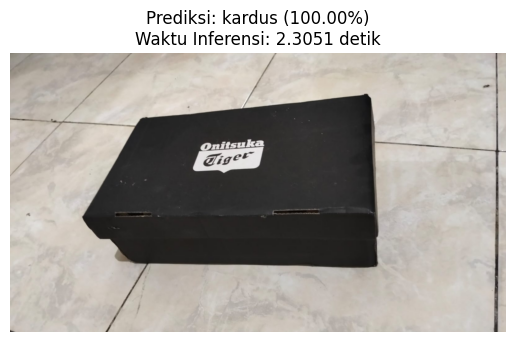

Model digunakan     : googlenet_inceptionv3_best.h5
Hasil Prediksi      : kardus
Tingkat Keyakinan   : 100.00%
Waktu Inferensi     : 2.3051 detik


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
from tensorflow.keras.preprocessing import image
from tensorflow import keras

# === Load model (support .h5 dan .keras) ===
model_path = 'googlenet_inceptionv3_best.h5'  # ganti ke .h5 atau .keras
model = keras.models.load_model(model_path)

# === Label kelas sesuai dataset ===
class_labels = ['botol', 'kaleng', 'kardus', 'organik']

# === Path gambar yang ingin diuji ===
img_path = r"D:\Skripsi\model\test.jpg"  # sesuaikan path

# === Preprocessing gambar ===
img = image.load_img(img_path, target_size=(299, 299))
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)  # batch size = 1

# === Inferensi + hitung waktu ===
start_time = time.time()
pred = model.predict(img_array, verbose=0)
end_time = time.time()

# === Hasil prediksi ===
pred_class = class_labels[np.argmax(pred)]
confidence = np.max(pred) * 100
inference_time = end_time - start_time

# === Tampilkan gambar & hasil ===
plt.imshow(image.load_img(img_path))
plt.title(
    f"Prediksi: {pred_class} ({confidence:.2f}%)\n"
    f"Waktu Inferensi: {inference_time:.4f} detik",
    fontsize=12
)
plt.axis('off')
plt.show()

# === Print ke terminal ===
print(f"Model digunakan     : {model_path}")
print(f"Hasil Prediksi      : {pred_class}")
print(f"Tingkat Keyakinan   : {confidence:.2f}%")
print(f"Waktu Inferensi     : {inference_time:.4f} detik")
